In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [23]:
df = pd.read_csv("IPL.csv")
df.head()


,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [24]:
print("Shape:", df.shape)
df.info()


Shape: (150460, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150460 entries, 0 to 150459
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          150460 non-null  int64 
 1   inning            150460 non-null  int64 
 2   batting_team      150460 non-null  object
 3   bowling_team      150460 non-null  object
 4   over              150460 non-null  int64 
 5   ball              150460 non-null  int64 
 6   batsman           150460 non-null  object
 7   non_striker       150460 non-null  object
 8   bowler            150460 non-null  object
 9   is_super_over     150460 non-null  int64 
 10  wide_runs         150460 non-null  int64 
 11  bye_runs          150460 non-null  int64 
 12  legbye_runs       150460 non-null  int64 
 13  noball_runs       150460 non-null  int64 
 14  penalty_runs      150460 non-null  int64 
 15  batsman_runs      150460 non-null  int64 
 16  extra_runs        

In [25]:
df.describe(include="all")


,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
count,150460.000000,150460.000000,150460,150460,150460.000000,150460.000000,150460,150460,150460,150460.000000,...,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,7438,7438,5369
unique,NaN,NaN,14,14,NaN,NaN,461,458,356,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,436,9,451
top,NaN,NaN,Mumbai Indians,Mumbai Indians,NaN,NaN,V Kohli,G Gambhir,Harbhajan Singh,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SK Raina,caught,KD Karthik
freq,NaN,NaN,18943,18879,NaN,NaN,3494,3635,2989,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,134,4373,127
mean,318.281317,1.482188,NaN,NaN,10.142649,3.616483,NaN,NaN,NaN,0.000538,...,0.004885,0.022232,0.004340,0.000066,1.222445,0.069022,1.291466,NaN,NaN,NaN
std,182.955531,0.501768,NaN,NaN,5.674338,1.807698,NaN,NaN,NaN,0.023196,...,0.114234,0.200104,0.072652,0.018229,1.594509,0.349667,1.583240,NaN,NaN,NaN
min,1.000000,1.000000,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
25%,161.000000,1.000000,NaN,NaN,5.000000,2.000000,NaN,NaN,NaN,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
50%,319.000000,1.000000,NaN,NaN,10.000000,4.000000,NaN,NaN,NaN,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,NaN,NaN,NaN
75%,476.000000,2.000000,NaN,NaN,15.000000,5.000000,NaN,NaN,NaN,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,NaN,NaN,NaN


In [26]:
df.isnull().sum()


match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
is_super_over            0
wide_runs                0
bye_runs                 0
legbye_runs              0
noball_runs              0
penalty_runs             0
batsman_runs             0
extra_runs               0
total_runs               0
player_dismissed    143022
dismissal_kind      143022
fielder             145091
dtype: int64

In [27]:
df.drop_duplicates(inplace=True)
print("After removing duplicates:", df.shape)


After removing duplicates: (150459, 21)


In [28]:
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col] = df[col].fillna("Unknown")
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(0)

df.isnull().sum()

match_id            0
inning              0
batting_team        0
bowling_team        0
over                0
ball                0
batsman             0
non_striker         0
bowler              0
is_super_over       0
wide_runs           0
bye_runs            0
legbye_runs         0
noball_runs         0
penalty_runs        0
batsman_runs        0
extra_runs          0
total_runs          0
player_dismissed    0
dismissal_kind      0
fielder             0
dtype: int64

In [29]:
df["Is_Boundary_4"] = (df["batsman_runs"] == 4).astype(int)
df["Is_Boundary_6"] = (df["batsman_runs"] == 6).astype(int)

df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder,Is_Boundary_4,Is_Boundary_6
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,Unknown,Unknown,Unknown,0,0
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,Unknown,Unknown,Unknown,0,0
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,4,0,4,Unknown,Unknown,Unknown,1,0
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,Unknown,Unknown,Unknown,0,0
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,2,2,Unknown,Unknown,Unknown,0,0


In [31]:
df.to_csv("IPL_BallByBall_Cleaned.csv", index=False)
print("Cleaned dataset saved as IPL_BallByBall_Cleaned.csv")


Cleaned dataset saved as IPL_BallByBall_Cleaned.csv


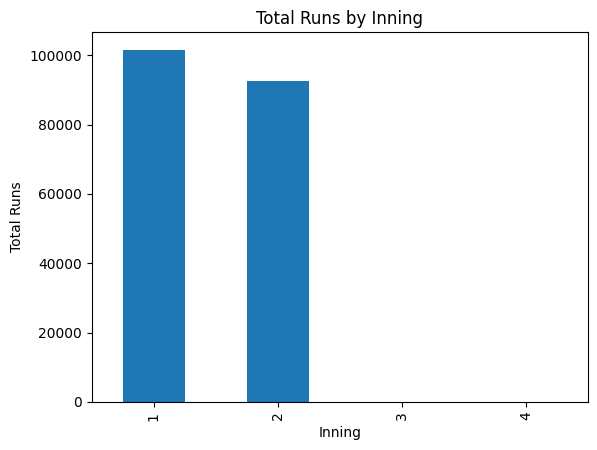

In [32]:
inning_runs = df.groupby("inning")["total_runs"].sum()
inning_runs.plot(kind="bar")
plt.title("Total Runs by Inning")
plt.xlabel("Inning")
plt.ylabel("Total Runs")
plt.show()


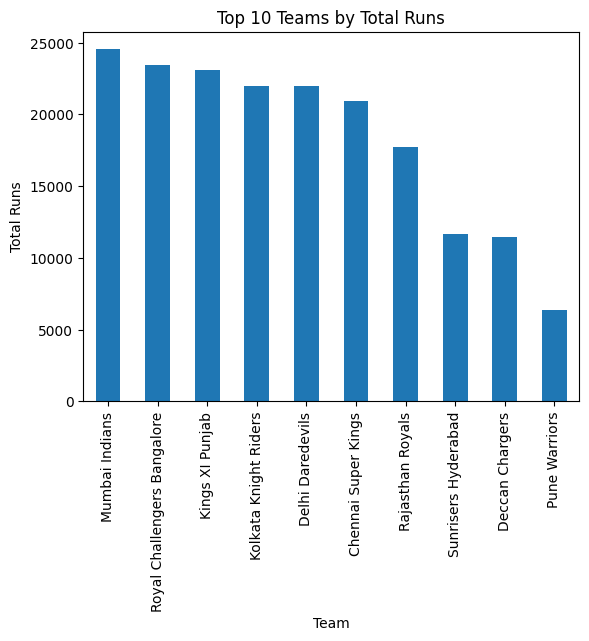

In [33]:
team_runs = df.groupby("batting_team")["total_runs"].sum().sort_values(ascending=False).head(10)
team_runs.plot(kind="bar")
plt.title("Top 10 Teams by Total Runs")
plt.xlabel("Team")
plt.ylabel("Total Runs")
plt.show()


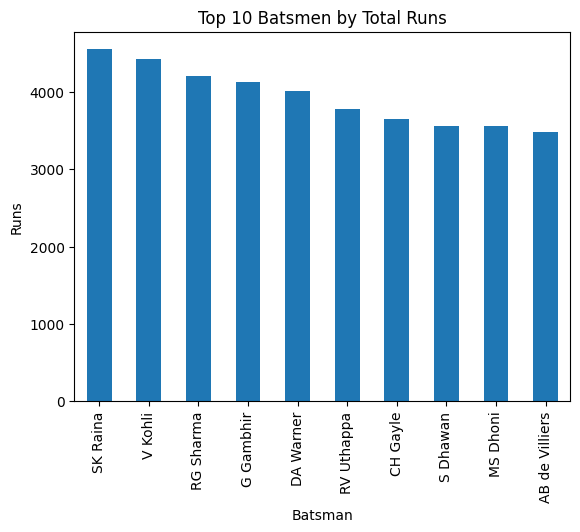

In [34]:
top_batsmen = df.groupby("batsman")["batsman_runs"].sum().sort_values(ascending=False).head(10)
top_batsmen.plot(kind="bar")
plt.title("Top 10 Batsmen by Total Runs")
plt.xlabel("Batsman")
plt.ylabel("Runs")
plt.show()


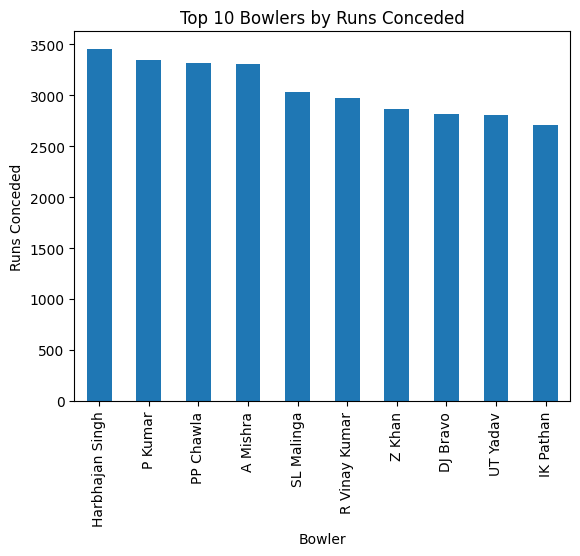

In [35]:
top_bowlers_conceded = df.groupby("bowler")["total_runs"].sum().sort_values(ascending=False).head(10)
top_bowlers_conceded.plot(kind="bar")
plt.title("Top 10 Bowlers by Runs Conceded")
plt.xlabel("Bowler")
plt.ylabel("Runs Conceded")
plt.show()


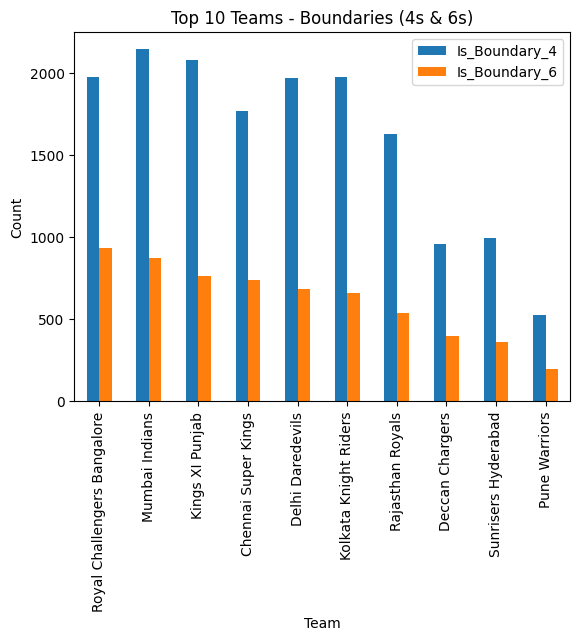

In [36]:
team_boundaries = df.groupby("batting_team")[["Is_Boundary_4", "Is_Boundary_6"]].sum().sort_values(by="Is_Boundary_6", ascending=False).head(10)
team_boundaries.plot(kind="bar")
plt.title("Top 10 Teams - Boundaries (4s & 6s)")
plt.xlabel("Team")
plt.ylabel("Count")
plt.show()


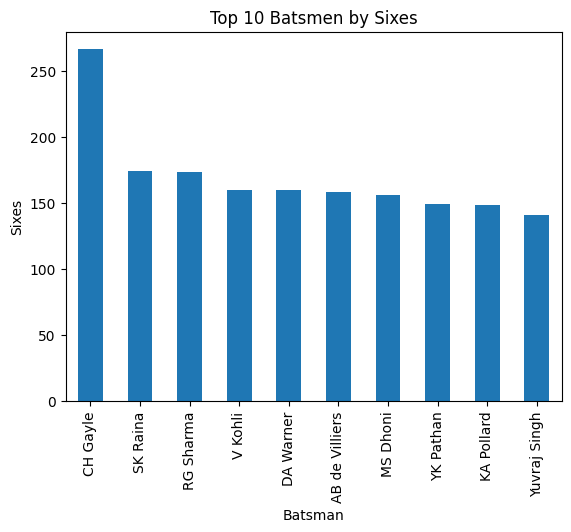

In [37]:
batsman_sixes = df.groupby("batsman")["Is_Boundary_6"].sum().sort_values(ascending=False).head(10)
batsman_sixes.plot(kind="bar")
plt.title("Top 10 Batsmen by Sixes")
plt.xlabel("Batsman")
plt.ylabel("Sixes")
plt.show()


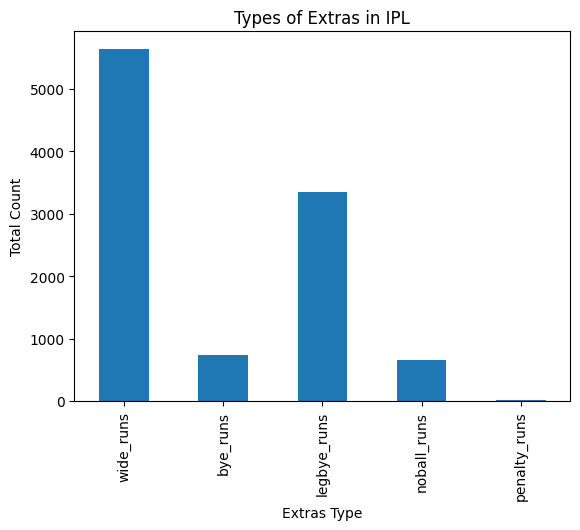

In [38]:
extras = df[["wide_runs","bye_runs","legbye_runs","noball_runs","penalty_runs"]].sum()
extras.plot(kind="bar")
plt.title("Types of Extras in IPL")
plt.xlabel("Extras Type")
plt.ylabel("Total Count")
plt.show()


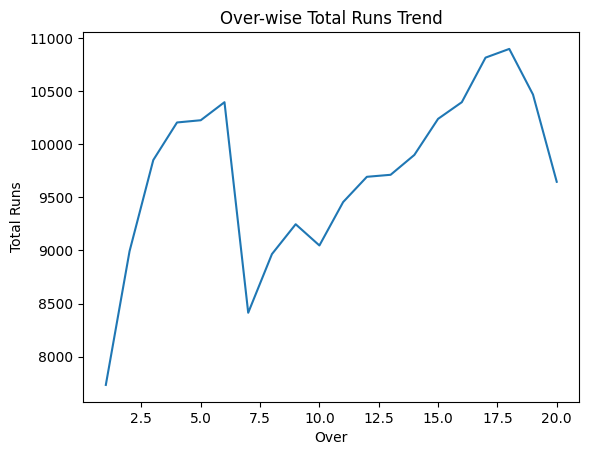

In [39]:
over_runs = df.groupby("over")["total_runs"].sum()
over_runs.plot(kind="line")
plt.title("Over-wise Total Runs Trend")
plt.xlabel("Over")
plt.ylabel("Total Runs")
plt.show()


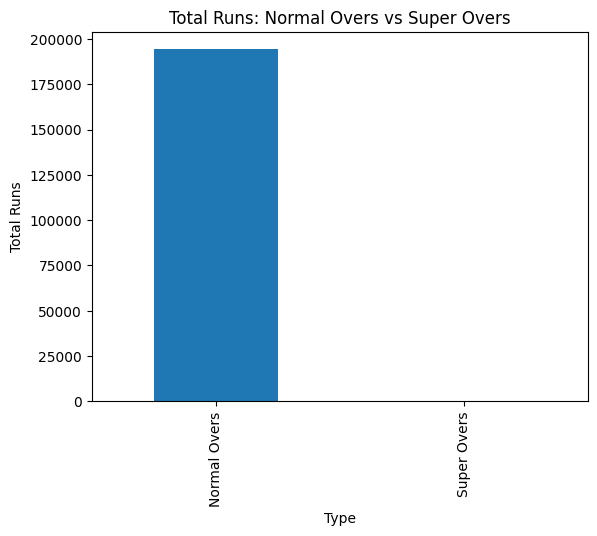

In [40]:
super_over_runs = df.groupby("is_super_over")["total_runs"].sum()
super_over_runs.index = ["Normal Overs", "Super Overs"]
super_over_runs.plot(kind="bar")
plt.title("Total Runs: Normal Overs vs Super Overs")
plt.xlabel("Type")
plt.ylabel("Total Runs")
plt.show()


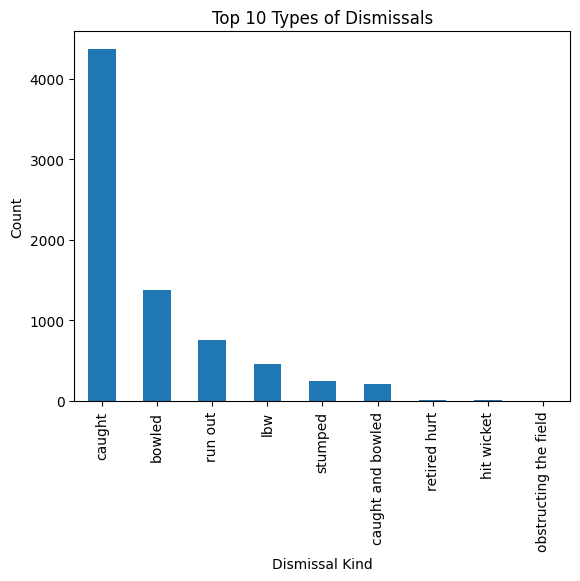

In [41]:
dismissal = df[df["dismissal_kind"] != "Unknown"]["dismissal_kind"].value_counts().head(10)
dismissal.plot(kind="bar")
plt.title("Top 10 Types of Dismissals")
plt.xlabel("Dismissal Kind")
plt.ylabel("Count")
plt.show()


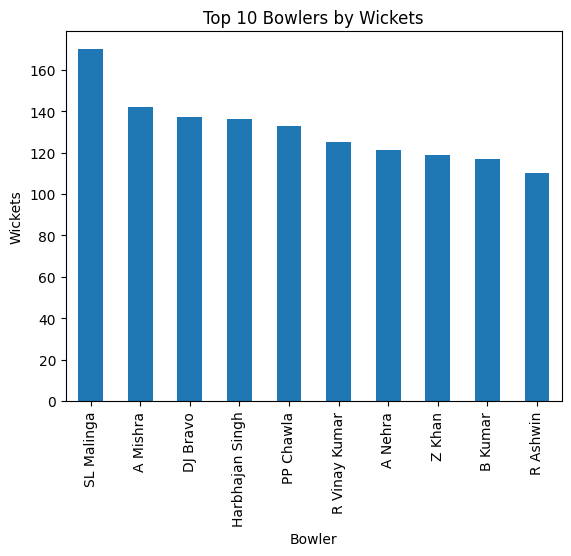

In [42]:
wickets = df[df["player_dismissed"] != "Unknown"]
top_wicket_bowlers = wickets["bowler"].value_counts().head(10)
top_wicket_bowlers.plot(kind="bar")
plt.title("Top 10 Bowlers by Wickets")
plt.xlabel("Bowler")
plt.ylabel("Wickets")
plt.show()


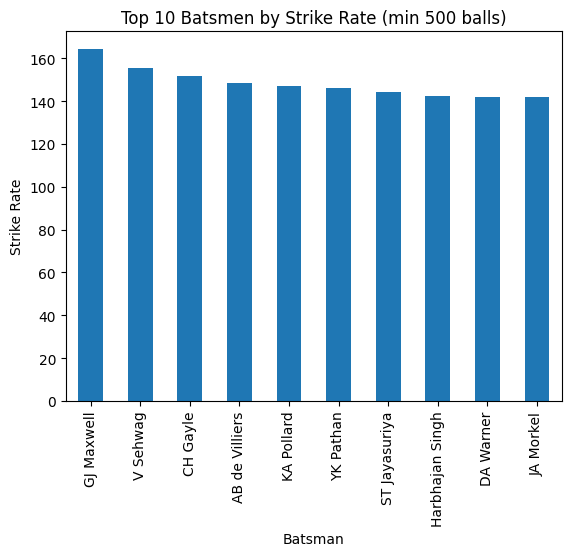

In [43]:
balls_faced = df[df["wide_runs"] == 0].groupby("batsman")["ball"].count()   # wides not counted as ball faced
runs_scored = df.groupby("batsman")["batsman_runs"].sum()

strike_rate = (runs_scored / balls_faced) * 100
sr_df = pd.DataFrame({"Balls": balls_faced, "Runs": runs_scored, "StrikeRate": strike_rate})
sr_df = sr_df[sr_df["Balls"] >= 500].sort_values("StrikeRate", ascending=False).head(10)

sr_df["StrikeRate"].plot(kind="bar")
plt.title("Top 10 Batsmen by Strike Rate (min 500 balls)")
plt.xlabel("Batsman")
plt.ylabel("Strike Rate")
plt.show()
